In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Benchmarking state preparation circuits

The `qldpc.circuits.benchmarking` sub-module provides methods to compute the logical error rates of state preparation circuits.

### imports and plotting code

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
import stim

from qldpc import circuits, codes, decoders

%matplotlib inline

In [3]:
def plot_sinter_results(stats: sinter.TaskStats) -> tuple[plt.Figure, plt.Axes]:
    """Plot sinter simulation results."""
    figure, axis = plt.subplots(figsize=(4, 3))
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["p"],
    )
    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.set_ylabel("logical error rate")
    axis.set_xlabel("physical error rate")
    axis.loglog()
    axis.grid(which="both")
    figure.tight_layout()
    return figure, axis


def plot_error_rates(
    error_rates: npt.NDArray[np.int_], logical_error_rates: npt.NDArray[np.int_]
) -> tuple[plt.Figure, plt.Axes]:
    """Plot logical error rates."""
    figure, axis = plt.subplots(figsize=(4, 3))
    axis.plot(error_rates, logical_error_rates, marker="o", linestyle="-")
    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.set_xlabel("physical error rate")
    axis.set_ylabel("logical error rate")
    axis.loglog()
    axis.grid(which="both")
    figure.tight_layout()
    return figure, axis


def plot_error_and_discard_rates(
    error_rates: npt.NDArray[np.int_],
    logical_error_rates: npt.NDArray[np.int_],
    discard_rates: npt.NDArray[np.int_],
) -> tuple[plt.Figure, plt.Axes]:
    """Plot logical error rates and discard rates."""
    figure, axes = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

    # logical error rates
    axes[0].plot(error_rates, logical_error_rates, marker="o", linestyle="-")
    axes[0].axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axes[0].set_xlabel("physical error rate")
    axes[0].set_ylabel("logical error rate")

    # discard rates
    axes[1].plot(error_rates, discard_rates, marker="o", linestyle="-")
    axes[1].set_xlabel("physical error rate")
    axes[1].set_ylabel("discard rate")

    for axis in axes:
        axis.loglog()
        axis.grid(which="both")
    figure.tight_layout()
    return figure, axes

### Steane code

The Steane code has well-known circuits for fault-tolerant logical state preparation.  The circuit below is taken from a [2016 paper by Goto](https://www.nature.com/articles/srep19578) (Figure 1c).

Computing logical error rates also requires us to choose:
1. A family of noise models that determine which errors occur, and how likely they are.  We'll use a depolarizing noise model family.
2. A decoder that identifies logical errors from syndrome data.  We'll use a lookup table decoder.

A potential point of confusion: the decoder here should be a `sinter.Decoder` that uses syndromes to infer which observables need to be flipped, not a `qldpc.decoders.Decoder` that uses syndromes to infer which physical error has occurred.

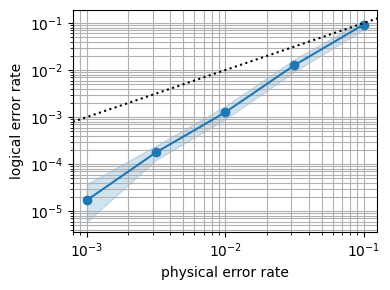

In [4]:
code = codes.SteaneCode()
state_prep_circuit = stim.Circuit("""
    # non-fault-tolerant state preparation
    H 0 2 4
    CX 0 3 2 1 4 5
    CX 0 1 2 6 4 3
    CX 2 5 3 6
    # flag errors in a logical Z representative
    H 7
    CZ 7 1 7 3 7 5
    MX 7
""")

# physical error rates to simulate, and single-parameter family of noise models used to add noise to the circuit
error_rates = np.logspace(-3, -1, 5)
noise_model_family = circuits.DepolarizingNoiseModel

# build sinter tasks to perform our simulations
tasks = circuits.get_state_prep_diagnostic_tasks(
    code, state_prep_circuit, error_rates, noise_model_family
)

# use a lookup table decoder for these simulations
sinter_decoder = decoders.SinterDecoder(with_lookup=True, max_weight=2)

# run simulations and collect statistics on error rates
stats = sinter.collect(
    tasks=tasks,
    decoders=["custom"],
    custom_decoders={"custom": sinter_decoder},
    num_workers=os.cpu_count() - 2,
    max_shots=10**6,
    max_errors=100,
)

# plot simulation results!
plot_sinter_results(stats)
plt.show()

### Post-selecting on flag qubit measurements

Many state preparation routines are repeat-until-success protocols, which use ancilla qubits to "flag" errors that may have occurred during state preparation.  If any flag qubit measurement has the wrong value (without loss of generality, 1 instead of 0), the state preparation routine restarts the protocol from scratch.  To identify the logical error rate of successful protocols, we need to post-select on the flag measurement outcomes.

We can post-select on state preparation flags by passing `post_select_on_flags=True`.  Unfortunately, a [`sinter` bug](https://github.com/quantumlib/Stim/pull/844) currently prevents us from post-selecting in `sinter` simulations, so we instead use the `circuits.get_logical_error_and_discard_rates` method.

(TODO: add example comparing with vs. without post-selection, using the circuit in Figure 2b of [arXiv:2603.04584v1](https://arxiv.org/abs/2603.04584).)

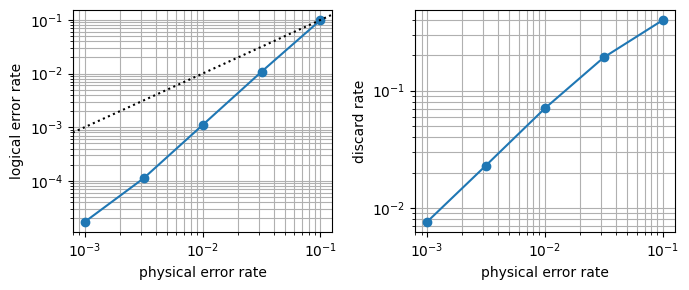

In [5]:
logical_error_rates, discard_rates = circuits.get_logical_error_and_discard_rates(
    code,
    state_prep_circuit,
    error_rates,
    noise_model_family,
    sinter_decoder=sinter_decoder,
    num_samples=10**6,
    post_select_on_flags=True,
)

# plot simulation results!
plot_error_and_discard_rates(error_rates, logical_error_rates, discard_rates)
plt.show()

### Non-fault-tolerant state preparation circuits

If a state preparation circuit is not fault-tolerant, logical error rates will always exceed physical error rates.

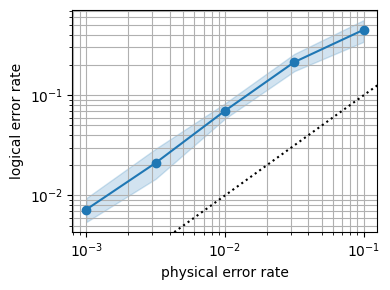

In [6]:
state_prep_circuit = circuits.get_encoding_circuit(code)

# build sinter tasks to perform our simulations
tasks = circuits.get_state_prep_diagnostic_tasks(
    code, state_prep_circuit, error_rates, noise_model_family
)

# run simulations and collect statistics on error rates
stats = sinter.collect(
    tasks=tasks,
    decoders=["custom"],
    custom_decoders={"custom": sinter_decoder},
    num_workers=os.cpu_count() - 2,
    max_shots=10**6,
    max_errors=100,
)

# plot simulation results!
plot_sinter_results(stats)
plt.show()